In [3]:
import numpy as np
import pandas as pd


In [14]:
df=pd.read_excel("/content/Data_Encoding.xlsx")

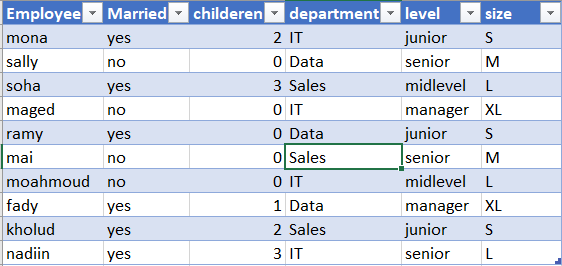

In [ ]:
#binary - > Married
#Nominal -> Department
#Ordinal -> Level

#Numeric Encoding (Label-Encoder)
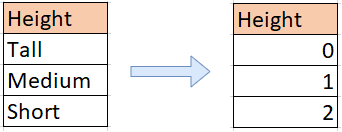

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
label_encoder=LabelEncoder()

In [7]:
df['Married']=label_encoder.fit_transform(df['Married'])

In [8]:
df

,Employee,Married,childeren,department,level,size
0,mona,1,2,IT,junior,S
1,sally,0,0,Data,senior,M
2,soha,1,3,Sales,midlevel,L
3,maged,0,0,IT,manager,XL
4,ramy,1,0,Data,junior,S
5,mai,0,0,Sales,senior,M
6,moahmoud,0,0,IT,midlevel,L
7,fady,1,1,Data,manager,XL
8,kholud,1,2,Sales,junior,S
9,nadiin,1,3,IT,senior,L


In [9]:
from sklearn.preprocessing import OrdinalEncoder

Ordinal_encoder = OrdinalEncoder(categories=[['S','M','L','XL','XXL']])

df['size'] = Ordinal_encoder.fit_transform(df[['size']])

In [10]:
df

,Employee,Married,childeren,department,level,size
0,mona,1,2,IT,junior,0.0
1,sally,0,0,Data,senior,1.0
2,soha,1,3,Sales,midlevel,2.0
3,maged,0,0,IT,manager,3.0
4,ramy,1,0,Data,junior,0.0
5,mai,0,0,Sales,senior,1.0
6,moahmoud,0,0,IT,midlevel,2.0
7,fady,1,1,Data,manager,3.0
8,kholud,1,2,Sales,junior,0.0
9,nadiin,1,3,IT,senior,2.0


In [11]:
df.replace(
    {
        'level' : {'junior' : 0, 'senior' : 1, 'midlevel' : 2 , 'manager' : 3}

    },inplace=True
)

/tmp/ipykernel_15771/3024473356.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(


In [12]:
df

,Employee,Married,childeren,department,level,size
0,mona,1,2,IT,0,0.0
1,sally,0,0,Data,1,1.0
2,soha,1,3,Sales,2,2.0
3,maged,0,0,IT,3,3.0
4,ramy,1,0,Data,0,0.0
5,mai,0,0,Sales,1,1.0
6,moahmoud,0,0,IT,2,2.0
7,fady,1,1,Data,3,3.0
8,kholud,1,2,Sales,0,0.0
9,nadiin,1,3,IT,1,2.0


In [ ]:
df.drop('Employee', axis=1 , inplace=True)

In [ ]:
df=pd.get_dummies(df,dtype=int)
df

,Married,childeren,level,size,department_Data,department_IT,department_Sales
0,1,2,0,0.0,0,1,0
1,0,0,1,1.0,1,0,0
2,1,3,2,2.0,0,0,1
3,0,0,3,3.0,0,1,0
4,1,0,0,0.0,1,0,0
5,0,0,1,1.0,0,0,1
6,0,0,2,2.0,0,1,0
7,1,1,3,3.0,1,0,0
8,1,2,0,0.0,0,0,1
9,1,3,1,2.0,0,1,0


In [15]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

df_new = encoder.fit_transform(df[['department']])

In [22]:
type(df_new)

scipy.sparse._csr.csr_matrix

In [ ]:
encoded_df = pd.DataFrame(
    df_new.toarray(),
    columns=encoder.get_feature_names_out(['department'])
)

In [ ]:
encoded_df

,department_Data,department_IT,department_Sales
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0
5,0.0,0.0,1.0
6,0.0,1.0,0.0
7,1.0,0.0,0.0
8,0.0,0.0,1.0
9,0.0,1.0,0.0


In [ ]:
df

,Married,childeren,department,level,size
0,1,2,IT,0,0.0
1,0,0,Data,1,1.0
2,1,3,Sales,2,2.0
3,0,0,IT,3,3.0
4,1,0,Data,0,0.0
5,0,0,Sales,1,1.0
6,0,0,IT,2,2.0
7,1,1,Data,3,3.0
8,1,2,Sales,0,0.0
9,1,3,IT,1,2.0


In [ ]:
df_final = pd.concat([df, encoded_df], axis=1)

In [ ]:
df_final

,Married,childeren,department,level,size,department_Data,department_IT,department_Sales
0,1,2,IT,0,0.0,0.0,1.0,0.0
1,0,0,Data,1,1.0,1.0,0.0,0.0
2,1,3,Sales,2,2.0,0.0,0.0,1.0
3,0,0,IT,3,3.0,0.0,1.0,0.0
4,1,0,Data,0,0.0,1.0,0.0,0.0
5,0,0,Sales,1,1.0,0.0,0.0,1.0
6,0,0,IT,2,2.0,0.0,1.0,0.0
7,1,1,Data,3,3.0,1.0,0.0,0.0
8,1,2,Sales,0,0.0,0.0,0.0,1.0
9,1,3,IT,1,2.0,0.0,1.0,0.0
